## Imports

Load required libraries for database access, data processing, and visualization.


In [33]:
import pyodbc
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt


## SQL Server connection (Docker)

Connect to a local SQL Server instance running in Docker.


In [34]:
conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost,1433;"
    "DATABASE=vt4;"
    "UID=sa;"
    "PWD=Strong!Passw0rd;"
    "TrustServerCertificate=yes;"
)


## SQL query (safe casting for text fields)

Explicit casts avoid schema inference issues for long text columns.


In [35]:
query = """
SELECT
    r.Id AS ReportId,
    ra.Id AS DataId,
    ra.UserId,
    ra.CreationDate,
    ra.StartedProcessingOn,
    ra.CompletionDate,
    DATEDIFF(MILLISECOND, ra.StartedProcessingOn, ra.CompletionDate) AS DurationMs,
    DATEDIFF(SECOND, ra.StartedProcessingOn, ra.CompletionDate) AS DurationSeconds,
    CASE
        WHEN ra.Cancelled = 1 THEN 'cancelled'
        WHEN ra.Failed = 1 OR ra.ErrorMessage IS NOT NULL THEN 'failed'
        ELSE 'success'
    END AS ExecutionStatus,
    ra.Failed,
    ra.Cancelled,
    CAST(ra.ErrorMessage AS NVARCHAR(MAX)) AS ErrorMessage,
    CAST(ra.Parameters AS NVARCHAR(MAX)) AS Parameters,
    r.ReportName,
    CAST(r.[File] AS NVARCHAR(255)) AS ControllerActionOrSP,
    r.QueueNumber AS ReportQueueId,
    r.Deprecated,
    r.Deleted,
    q.ReportType,
    q.ReportSize,
    q.QueueNumber AS QueueNumber
FROM reportsdata ra
JOIN reports r ON ra.ReportId = r.Id
JOIN ReportQueues q ON q.Id = r.QueueNumber
ORDER BY ra.CompletionDate DESC;
"""


## Fetch data into Polars

Rows are normalized to tuples to avoid schema mismatches.


In [36]:
with pyodbc.connect(conn_str) as conn:
    cur = conn.cursor()
    cur.execute(query)
    columns = [c[0] for c in cur.description]
    rows = [tuple(r) for r in cur.fetchall()]

df_raw = pl.DataFrame(
    rows,
    schema=columns,
    infer_schema_length=None
)

df_raw.shape


C:\Users\dante\AppData\Local\Temp\ipykernel_43984\473214297.py:7: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  df_raw = pl.DataFrame(


(660977, 21)

## Normalize column names and types

Standardize naming and parse timestamps.


In [37]:
df = (
    df_raw.rename({
        "StartedProcessingOn": "started_at",
        "CompletionDate": "completed_at",
        "DurationSeconds": "duration_seconds",
        "DurationMs": "duration_ms",
        "ExecutionStatus": "execution_status",
    })
    .with_columns([
        pl.col("started_at").cast(pl.Datetime, strict=False),
        pl.col("completed_at").cast(pl.Datetime, strict=False),
        pl.col("duration_seconds").cast(pl.Int64, strict=False),
    ])
)


## Remove duplicate executions

Each execution is uniquely identified by DataId.


In [38]:
df = df.unique(subset=["DataId"])
df.shape


(660977, 21)

## Recompute duration where missing

Duration is derived from timestamps when not explicitly provided.


In [39]:
df = df.with_columns(
    pl.when(
        pl.col("duration_seconds").is_null() &
        pl.col("completed_at").is_not_null()
    )
    .then(
        (pl.col("completed_at").dt.epoch("ms") -
         pl.col("started_at").dt.epoch("ms")) // 1000
    )
    .otherwise(pl.col("duration_seconds"))
    .alias("duration_seconds")
)


## Drop redundant units

Milliseconds are removed to keep a single time unit.


In [40]:
df = df.drop("duration_ms", strict=False)


## Derive temporal features

Create hourly and calendar-based features for analysis.


In [41]:
df = df.with_columns([
    pl.col("started_at").dt.truncate("1h").alias("time_hour"),
    pl.col("started_at").dt.hour().alias("hour_of_day"),
    pl.col("started_at").dt.weekday().alias("day_of_week"),
    (pl.col("started_at").dt.weekday() < 5).alias("is_business_day"),
    (
        pl.col("started_at").dt.date().dt.month_end()
        == pl.col("started_at").dt.date()
    ).alias("is_end_of_month"),
])


## Normalize Deprecated and Deleted flags

Convert mixed representations to boolean.


In [42]:
df = df.with_columns([
    pl.col("Deprecated")
      .cast(pl.Utf8, strict=False)
      .str.to_lowercase()
      .is_in(["1", "true", "t", "yes", "y"])
      .alias("Deprecated_bool"),

    pl.col("Deleted")
      .cast(pl.Utf8, strict=False)
      .str.to_lowercase()
      .is_in(["1", "true", "t", "yes", "y"])
      .alias("Deleted_bool"),
])


## Filter valid executions

Keep only successful executions with positive duration and active reports.


In [43]:
valid_executions = df.filter(
    (pl.col("execution_status") == "success") &
    (pl.col("duration_seconds") > 0) &
    (~pl.col("Deprecated_bool")) &
    (~pl.col("Deleted_bool"))
)

valid_executions.shape


(453273, 27)

## Impact-based critical report analysis

Criticality is defined by total compute time rather than average duration.


In [44]:
critical_reports = (
    valid_executions.group_by("ReportName")
    .agg([
        pl.len().alias("total_executions"),
        pl.col("UserId").n_unique().alias("unique_users"),
        pl.col("duration_seconds").mean().alias("avg_duration"),
        pl.col("duration_seconds").median().alias("median_duration"),
        pl.col("duration_seconds").quantile(0.95).alias("p95_duration"),
        pl.col("duration_seconds").sum().alias("total_compute_time_s"),
        pl.col("is_business_day").mean().alias("pct_business_day"),
        pl.col("is_end_of_month").mean().alias("pct_end_of_month"),
        pl.col("ReportType").first().alias("report_type"),
        pl.col("ReportSize").first().alias("report_size"),
    ])
    .with_columns([
        pl.col("total_compute_time_s").alias("impact_score"),
        (pl.col("p95_duration") / pl.col("median_duration"))
        .alias("variability_ratio"),
    ])
    .sort("impact_score", descending=True)
)

critical_reports.head(20)


ReportName,total_executions,unique_users,avg_duration,median_duration,p95_duration,total_compute_time_s,pct_business_day,pct_end_of_month,report_type,report_size,impact_score,variability_ratio
str,u32,u32,f64,f64,f64,i64,f64,f64,str,str,i64,f64
"""Screening Report""",29859,4414,69.10275,3.0,439.0,2063339,0.820188,0.040524,"""NR""","""S""",2063339,146.333333
"""PMR""",42035,3070,30.30289,15.0,101.0,1273782,0.838516,0.039895,"""NR""","""M""",1273782,6.733333
"""Screening Review Report""",27979,2918,42.184638,2.0,232.0,1180284,0.814075,0.037028,"""NR""","""S""",1180284,116.0
"""Missouri Invoice (New)""",35303,1200,27.755205,6.0,107.0,979842,0.795966,0.09138,"""NR""","""M""",979842,17.833333
"""MIECHV Form 1 IL""",34193,2193,26.453134,10.0,90.0,904512,0.819232,0.056064,"""NR""","""M""",904512,9.0
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Visit Record Summary""",102020,4236,2.866928,1.0,11.0,292484,0.7713,0.044187,"""NR""","""S""",292484,11.0
"""MIECHV Form 2 Illinois""",18081,1020,14.623583,8.0,45.0,264409,0.813893,0.039212,"""NR""","""M""",264409,5.625
"""Family-Centered Assessment Com…",15559,2342,11.73533,2.0,67.0,182590,0.835658,0.035992,"""NR""","""S""",182590,33.5


## Plot critical reports by impact

Visualize the highest operational cost reports.


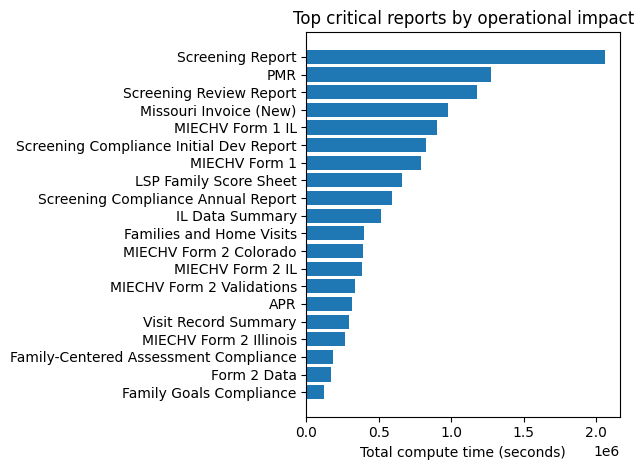

In [45]:
top = critical_reports.head(20)

plt.figure()
plt.barh(
    top["ReportName"][::-1],
    top["impact_score"][::-1]
)
plt.xlabel("Total compute time (seconds)")
plt.title("Top critical reports by operational impact")
plt.tight_layout()
plt.show()


## Failure analysis by report

Measure failure and cancellation rates independently from performance metrics.


In [46]:
failure_analysis = (
    df.group_by("ReportName")
    .agg([
        pl.len().alias("total_attempts"),
        (pl.col("execution_status") == "failed").sum().alias("failures"),
        (pl.col("execution_status") == "cancelled").sum().alias("cancellations"),
    ])
    .with_columns(
        ((pl.col("failures") + pl.col("cancellations")) /
         pl.col("total_attempts") * 100)
        .alias("failure_rate_pct")
    )
    .filter(pl.col("total_attempts") >= 10)
    .sort("failure_rate_pct", descending=True)
)

failure_analysis.head(20)


ReportName,total_attempts,failures,cancellations,failure_rate_pct
str,u32,u32,u32,f64
"""Group Meetings""",24,4,0,16.666667
"""Staffing Email List""",171,7,0,4.093567
"""IL Data Summary""",5149,0,182,3.534667
"""Form 2 Data""",657,9,8,2.587519
"""IL Report Card""",392,0,5,1.27551
…,…,…,…,…
"""Screening Review Report""",36258,0,135,0.372332
"""Performance Measures Report""",40229,0,127,0.315693
"""Performance Measures Report 20…",9232,0,28,0.303293


## Hourly load and compute cost

Analyze execution volume and compute usage by hour of day.


In [47]:
hourly_load = (
    valid_executions.group_by("hour_of_day")
    .agg([
        pl.len().alias("executions"),
        pl.col("duration_seconds").sum().alias("total_compute_seconds"),
    ])
    .sort("hour_of_day")
)

hourly_load


hour_of_day,executions,total_compute_seconds
i8,u32,i64
0,1821,66592
1,983,71088
2,491,18820
3,345,7873
4,377,20800
…,…,…
19,9835,445587
20,8078,304240
21,6811,189886


## Plot hourly demand and cost


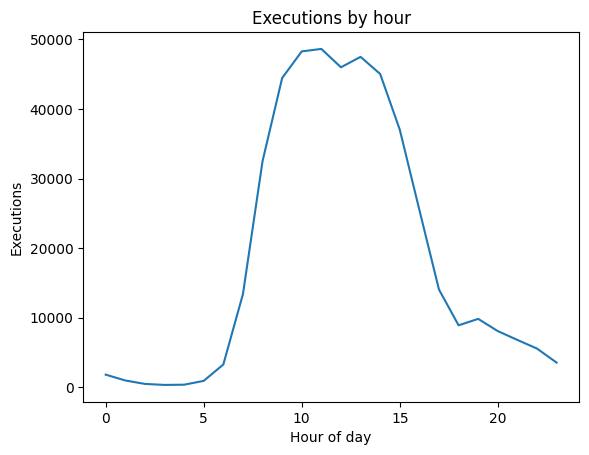

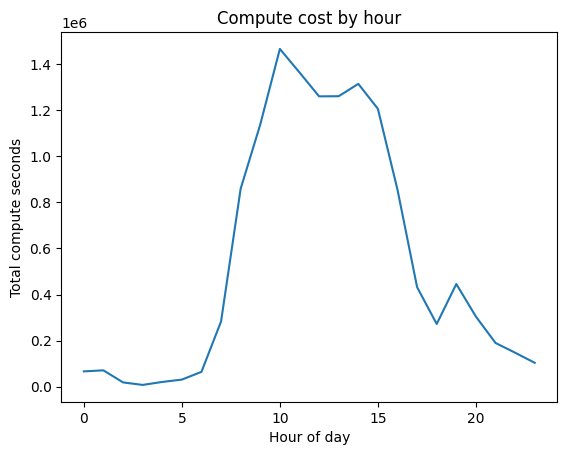

In [48]:
plt.figure()
plt.plot(hourly_load["hour_of_day"], hourly_load["executions"])
plt.xlabel("Hour of day")
plt.ylabel("Executions")
plt.title("Executions by hour")
plt.show()

plt.figure()
plt.plot(hourly_load["hour_of_day"], hourly_load["total_compute_seconds"])
plt.xlabel("Hour of day")
plt.ylabel("Total compute seconds")
plt.title("Compute cost by hour")
plt.show()


## Save outputs

Persist cleaned data and EDA results for reproducibility.


In [49]:
df.write_csv("report_executions_clean_v1.csv")
critical_reports.write_csv("eda_critical_reports.csv")
failure_analysis.write_csv("eda_failure_analysis.csv")
hourly_load.write_csv("eda_hourly_load.csv")

"Saved all outputs."


'Saved all outputs.'